# Deep Learning

## Introduction

Deep learning is a family of methods based on artificial neural networks that learn hierarchical representations of data. Over the past decade, deep learning has achieved remarkable success in computer vision, natural language processing, protein structure prediction, and many other domains.

In this lecture, we will cover:

* A brief history of neural networks
* From linear models to neural networks
* Activation functions and why they matter
* Forward propagation
* Loss functions and their connection to maximum likelihood
* Backpropagation and computational graphs
* Building and training neural networks in PyTorch
* Practical tips: learning rate, batch size, overfitting, regularization
* PyTorch Lightning

You already know gradient descent and optimization from Module 2. Deep learning builds directly on those foundations. The key insight is that neural networks are just compositions of simple differentiable functions, and we can optimize their parameters with gradient descent using the chain rule.

![xkcd 1838: Machine Learning](https://imgs.xkcd.com/comics/machine_learning.png)

## A Brief History of Neural Networks

Neural networks have a long and turbulent history, marked by cycles of enthusiasm and disappointment.

**The birth of the idea (1940s-1960s).** In 1943, McCulloch and Pitts proposed the first mathematical model of a biological neuron as a binary threshold unit. In 1957, Kolmogorov proved his superposition theorem: any continuous multivariate function can be represented as a composition of continuous univariate functions and addition. This result, while not originally about neural networks, later provided theoretical motivation for why networks with hidden layers can represent complex functions. In 1958, Rosenblatt built the Perceptron, a single-layer network that could learn to classify simple patterns. The media heralded it as a step toward thinking machines.

**The first AI winter (1969-1980s).** In 1969, Minsky and Papert published *Perceptrons*, demonstrating that single-layer networks cannot learn even simple functions like XOR. Combined with broader disillusionment in AI research and reduced government funding, interest in neural networks dried up.

**Backpropagation and revival (1986-1990s).** Rumelhart, Hinton, and Williams popularized backpropagation in 1986, enabling training of multilayer networks. In 1989, Cybenko proved the universal approximation theorem, showing that a single hidden layer with sigmoid activations can approximate any continuous function to arbitrary precision. That same year, LeCun applied CNNs to handwritten digit recognition (LeNet). However, training deep networks remained difficult, and simpler methods like SVMs often performed better in practice.

**The deep learning revolution (2006-present).** Hinton's work on deep belief networks (2006) and the term "deep learning" reignited interest. The breakthrough came in 2012 when AlexNet, a deep CNN trained on GPUs, won the ImageNet competition by a large margin. Key developments since then include:

- **2014**: Generative adversarial networks (GANs) and attention mechanisms
- **2016**: AlphaGo defeats the world Go champion using deep reinforcement learning
- **2017**: The Transformer architecture ("Attention Is All You Need")
- **2018+**: BERT, GPT, and modern large language models
- **2020**: AlphaFold solves protein structure prediction
- **2020-2022**: Diffusion models (DDPM, DALL-E 2, Stable Diffusion) enable high-quality image generation
- **2024-2025**: LLM-powered coding agents (Claude Code, Codex CLI, Cursor) automate software engineering tasks

The core algorithm, backpropagation, has remained essentially unchanged since 1986. What changed was data, compute, and better engineering (ReLU activations, batch normalization, residual connections, and the Transformer architecture).

## From Linear Models to Neural Networks

### Linear regression as a computational graph

Let's start from something familiar. In linear regression, we model:

$$\hat{y} = X\beta$$

where $X$ is an $n \times p$ design matrix and $\beta$ is a $p$-dimensional coefficient vector.

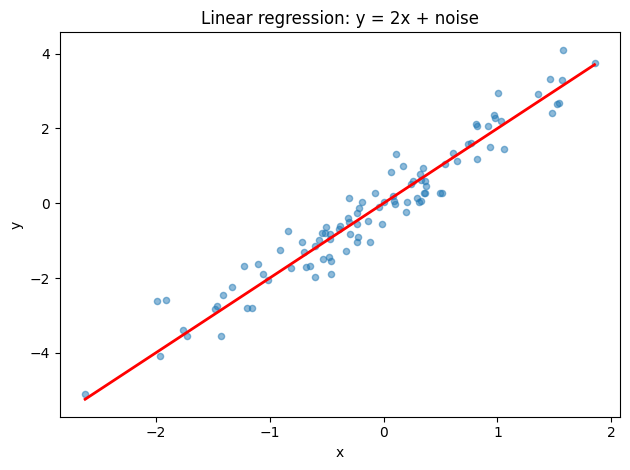

In [24]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)
n, p = 100, 1
X = np.random.randn(n, p)
beta_true = np.array([2.0])
y = X @ beta_true + 0.5 * np.random.randn(n)

plt.scatter(X, y, alpha=0.5, s=20)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression: y = 2x + noise")
plt.plot(X[np.argsort(X[:, 0])], (X @ beta_true)[np.argsort(X[:, 0])], 'r-', linewidth=2)
plt.tight_layout()
plt.savefig("figs/deep-learning-linear-data.png", dpi=150, bbox_inches="tight")

This is a single linear transformation. What if the relationship between $X$ and $y$ is nonlinear?

### The limits of linearity

Linear models can only capture linear relationships. Even with polynomial features, we need to manually specify the basis functions. Consider data that follows a sinusoidal pattern:

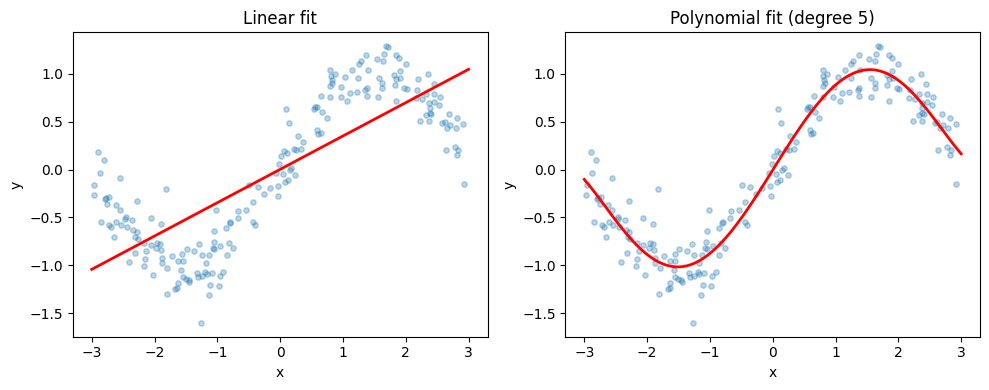

In [25]:
np.random.seed(42)
X_nl = np.random.uniform(-3, 3, (200, 1))
y_nl = np.sin(X_nl[:, 0]) + 0.2 * np.random.randn(200)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Linear fit
from numpy.polynomial import polynomial as P
coefs = np.polyfit(X_nl[:, 0], y_nl, 1)
x_plot = np.linspace(-3, 3, 100)
axes[0].scatter(X_nl, y_nl, alpha=0.3, s=15)
axes[0].plot(x_plot, np.polyval(coefs, x_plot), 'r-', linewidth=2)
axes[0].set_title("Linear fit")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Polynomial fit (degree 5)
coefs5 = np.polyfit(X_nl[:, 0], y_nl, 5)
axes[1].scatter(X_nl, y_nl, alpha=0.3, s=15)
axes[1].plot(x_plot, np.polyval(coefs5, x_plot), 'r-', linewidth=2)
axes[1].set_title("Polynomial fit (degree 5)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.savefig("figs/deep-learning-nonlinear.png", dpi=150, bbox_inches="tight")

The polynomial fit does better, but we had to choose the degree manually. Neural networks learn nonlinear transformations automatically from data.

### The perceptron: a single neuron

A single neuron (perceptron) computes:

$$z = w^T x + b, \quad a = \sigma(z)$$

where $w$ is a weight vector, $b$ is a bias (intercept), and $\sigma$ is an activation function. Compare this to logistic regression:

$$P(y=1 \mid x) = \text{sigmoid}(w^T x + b)$$

A single neuron with a sigmoid activation **is** logistic regression. Neural networks generalize this by stacking many neurons in layers.

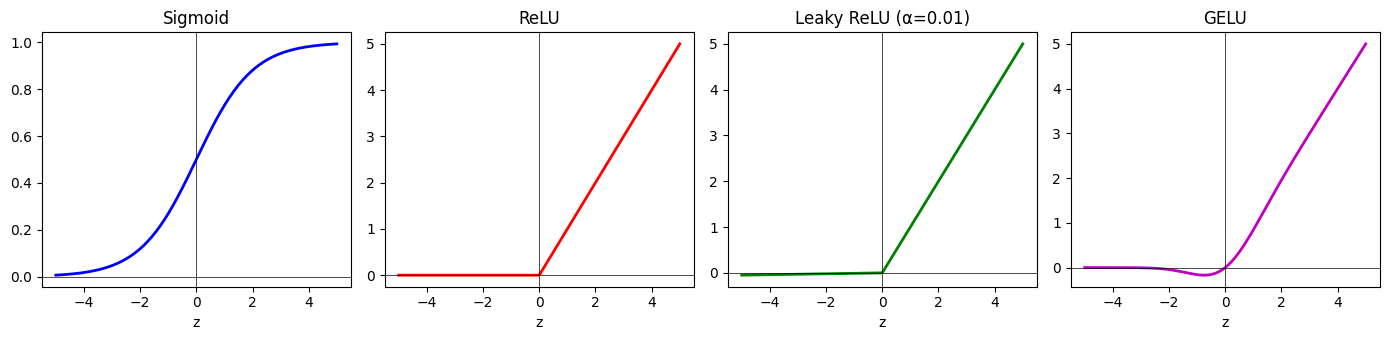

In [26]:
from scipy.stats import norm

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def gelu(z):
    return z * norm.cdf(z)

z = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

axes[0].plot(z, sigmoid(z), 'b-', linewidth=2)
axes[0].set_title("Sigmoid")
axes[0].set_xlabel("z")
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].axvline(x=0, color='k', linewidth=0.5)

axes[1].plot(z, relu(z), 'r-', linewidth=2)
axes[1].set_title("ReLU")
axes[1].set_xlabel("z")
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].axvline(x=0, color='k', linewidth=0.5)

axes[2].plot(z, leaky_relu(z), 'g-', linewidth=2)
axes[2].set_title("Leaky ReLU (α=0.01)")
axes[2].set_xlabel("z")
axes[2].axhline(y=0, color='k', linewidth=0.5)
axes[2].axvline(x=0, color='k', linewidth=0.5)

axes[3].plot(z, gelu(z), 'm-', linewidth=2)
axes[3].set_title("GELU")
axes[3].set_xlabel("z")
axes[3].axhline(y=0, color='k', linewidth=0.5)
axes[3].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig("figs/deep-learning-activations.png", dpi=150, bbox_inches="tight")

## Activation Functions

Activation functions introduce nonlinearity into the network. Without them, stacking linear layers would just produce another linear transformation (since the composition of linear functions is linear).

### Why nonlinearity is essential

If we stack two linear layers: $h = W_2(W_1 x + b_1) + b_2 = W_2 W_1 x + W_2 b_1 + b_2$. This is just another linear function $Ax + c$ where $A = W_2 W_1$. No matter how many linear layers we stack, the result is always linear.

### Common activation functions

**Sigmoid**: $\sigma(z) = \frac{1}{1+e^{-z}}$. Outputs values in $(0, 1)$. Used in the output layer for binary classification. Suffers from vanishing gradients when $|z|$ is large, because the derivative approaches zero.

**ReLU** (Rectified Linear Unit): $\text{ReLU}(z) = \max(0, z)$. The most widely used activation for hidden layers. Computationally efficient and does not saturate for positive values. Gradient is either 0 or 1, which avoids vanishing gradients. Can "die" if inputs are always negative (output is always 0).

**Leaky ReLU**: $\text{LeakyReLU}(z) = \max(\alpha z, z)$ where $\alpha$ is a small constant (typically 0.01). Fixes the "dying ReLU" problem by allowing a small gradient when $z < 0$.

**GELU** (Gaussian Error Linear Unit): $\text{GELU}(z) = z \cdot \Phi(z)$ where $\Phi$ is the standard normal CDF. Used in modern architectures like Transformers and BERT. Smoothly gates values rather than hard-thresholding like ReLU.

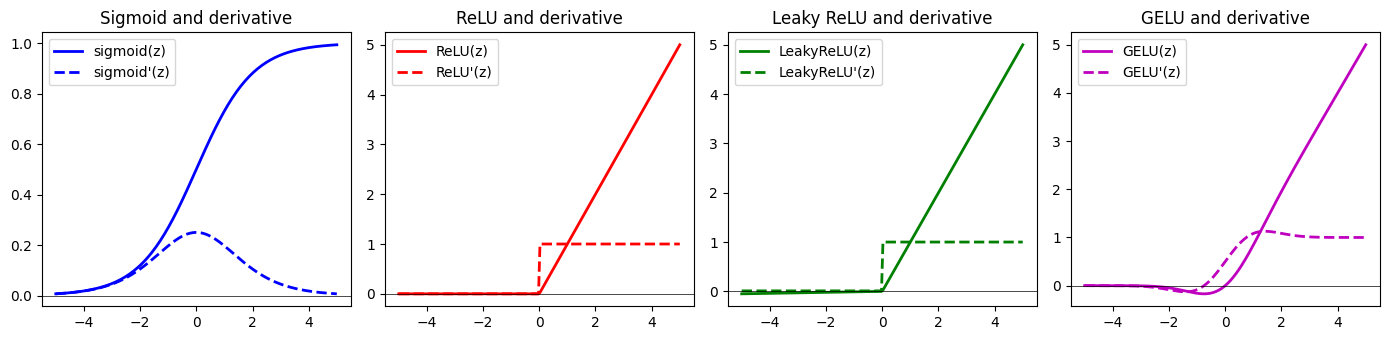

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

z = np.linspace(-5, 5, 200)

# Sigmoid and its derivative
sig = sigmoid(z)
sig_deriv = sig * (1 - sig)
axes[0].plot(z, sig, 'b-', linewidth=2, label="sigmoid(z)")
axes[0].plot(z, sig_deriv, 'b--', linewidth=2, label="sigmoid'(z)")
axes[0].set_title("Sigmoid and derivative")
axes[0].legend()
axes[0].axhline(y=0, color='k', linewidth=0.5)

# ReLU and its derivative
r = relu(z)
r_deriv = (z > 0).astype(float)
axes[1].plot(z, r, 'r-', linewidth=2, label="ReLU(z)")
axes[1].plot(z, r_deriv, 'r--', linewidth=2, label="ReLU'(z)")
axes[1].set_title("ReLU and derivative")
axes[1].legend()
axes[1].axhline(y=0, color='k', linewidth=0.5)

# Leaky ReLU and its derivative
lr_vals = leaky_relu(z)
lr_deriv = np.where(z > 0, 1.0, 0.01)
axes[2].plot(z, lr_vals, 'g-', linewidth=2, label="LeakyReLU(z)")
axes[2].plot(z, lr_deriv, 'g--', linewidth=2, label="LeakyReLU'(z)")
axes[2].set_title("Leaky ReLU and derivative")
axes[2].legend()
axes[2].axhline(y=0, color='k', linewidth=0.5)

# GELU and its derivative
g = gelu(z)
g_deriv = norm.cdf(z) + z * norm.pdf(z)
axes[3].plot(z, g, 'm-', linewidth=2, label="GELU(z)")
axes[3].plot(z, g_deriv, 'm--', linewidth=2, label="GELU'(z)")
axes[3].set_title("GELU and derivative")
axes[3].legend()
axes[3].axhline(y=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig("figs/deep-learning-activation-derivs.png", dpi=150, bbox_inches="tight")

Notice how the sigmoid derivative becomes very small when $|z|$ is large. This is the **vanishing gradient problem**: during backpropagation, gradients shrink exponentially as they pass through many layers with saturating activations. ReLU, Leaky ReLU, and GELU avoid this because their derivatives remain nonzero for positive inputs.

### Question

Suppose you have a 10-layer network where every hidden layer uses sigmoid activation.

In [28]:
# Sigmoid derivative at z = 5
z = 5.0
sig = 1 / (1 + np.exp(-z))
sig_deriv = sig * (1 - sig)
print(f"sigmoid'({z}) = {sig_deriv:.4f}")  # approximately 0.0067

sigmoid'(5.0) = 0.0066


If gradients are multiplied through 10 such layers, roughly how much does the gradient shrink from the output layer to the first layer?

### Answer

The gradient is multiplied by the derivative at each layer. With 10 layers: $0.0067^{10} \approx 2.1 \times 10^{-22}$. This is essentially zero, meaning the first layers receive virtually no gradient signal and cannot learn. This is why deep networks with sigmoid activations are extremely hard to train, and why ReLU (derivative = 1 for positive inputs) was a breakthrough for training deep networks.

## Multilayer Neural Networks

### Architecture

A feedforward neural network consists of:

- **Input layer**: the feature vector $x \in \mathbb{R}^p$
- **Hidden layers**: intermediate representations $h^{(l)}$ for $l = 1, \ldots, L$
- **Output layer**: the prediction $\hat{y}$

Each hidden layer applies: $h^{(l)} = \sigma(W^{(l)} h^{(l-1)} + b^{(l)})$

where $W^{(l)}$ is the weight matrix and $b^{(l)}$ is the bias vector for layer $l$, and $h^{(0)} = x$.

### Forward propagation

Forward propagation computes the output by passing the input through each layer sequentially. Let's trace through a small 2-layer network.

In [29]:
np.random.seed(0)

# Network: 2 inputs -> 3 hidden -> 1 output
W1 = np.random.randn(2, 3) * 0.5  # (input_dim, hidden_dim)
b1 = np.zeros(3)
W2 = np.random.randn(3, 1) * 0.5  # (hidden_dim, output_dim)
b2 = np.zeros(1)

def forward(x, W1, b1, W2, b2):
    """Forward pass through a 2-layer network."""
    z1 = x @ W1 + b1            # linear transform: (n, 2) @ (2, 3) = (n, 3)
    h1 = relu(z1)               # activation: (n, 3)
    z2 = h1 @ W2 + b2           # linear transform: (n, 3) @ (3, 1) = (n, 1)
    return z2, h1               # return output and hidden activations

# Example: forward pass on a single input
x_example = np.array([[1.0, -0.5]])
output, hidden = forward(x_example, W1, b1, W2, b2)

print(f"Input: {x_example}")
print(f"Hidden layer (after ReLU): {hidden}")
print(f"Output: {output}")

Input: [[ 1.  -0.5]]
Hidden layer (after ReLU): [[0.32180287 0.         0.73368846]]
Output: [[0.11500535]]


Each layer is just a matrix multiplication followed by a nonlinear activation. The entire network is a composition of these operations, forming a computational graph.

### Visualizing what hidden layers learn

Let's build a simple network from scratch and visualize how hidden layers transform the input space to solve a nonlinear classification problem (two moons).

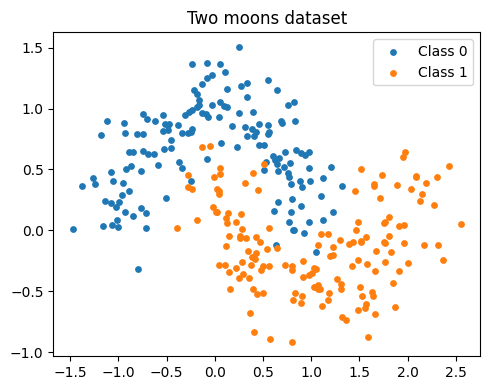

In [30]:
from sklearn.datasets import make_moons

np.random.seed(42)
X_moons, y_moons = make_moons(n_samples=300, noise=0.2)

plt.figure(figsize=(5, 4))
plt.scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], s=15, label="Class 0")
plt.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], s=15, label="Class 1")
plt.title("Two moons dataset")
plt.legend()
plt.tight_layout()
plt.savefig("figs/deep-learning-two-moons.png", dpi=150, bbox_inches="tight")

The two moons cannot be separated by a line. A neural network learns a nonlinear transformation of the input space that makes the classes linearly separable in the hidden layer's representation.

### Universal approximation

A single hidden layer with sufficiently many neurons can approximate any continuous function to arbitrary precision (the Universal Approximation Theorem). This does not mean a single hidden layer is always practical. Deeper networks can represent the same functions with exponentially fewer parameters.

### Question

Consider the following 3-layer network. How many trainable parameters (weights and biases) does it have?

In [31]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(5, 10),   # input -> hidden 1
    nn.ReLU(),
    nn.Linear(10, 10),  # hidden 1 -> hidden 2
    nn.ReLU(),
    nn.Linear(10, 3),   # hidden 2 -> output
)

### Answer

Layer 1: $5 \times 10$ weights + $10$ biases = 60. Layer 2: $10 \times 10$ weights + $10$ biases = 110. Output layer: $10 \times 3$ weights + $3$ biases = 33. Total = 60 + 110 + 33 = **203** parameters. Each connection between neurons has a weight, and each neuron (except in the input layer) has a bias.

## Loss Functions

The loss function measures how far the network's predictions are from the true values. Choosing the right loss function is directly connected to the statistical concept of maximum likelihood estimation.

### Mean squared error (regression)

For regression, we typically minimize the mean squared error:

$$\mathcal{L}_{\text{MSE}} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$$

This is equivalent to maximizing the log-likelihood under a Gaussian noise model: $y_i \sim \mathcal{N}(\hat{y}_i, \sigma^2)$.

### Cross-entropy loss (classification)

For binary classification, the cross-entropy loss is:

$$\mathcal{L}_{\text{CE}} = -\frac{1}{n}\sum_{i=1}^n \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

where $\hat{p}_i = \sigma(z_i)$ is the predicted probability. This is the negative log-likelihood of a Bernoulli model, exactly the same objective as logistic regression.

For multi-class classification with $K$ classes, we use the softmax function and categorical cross-entropy:

$$\hat{p}_k = \text{softmax}(z)_k = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}, \quad \mathcal{L} = -\frac{1}{n}\sum_{i=1}^n \sum_{k=1}^K y_{ik} \log(\hat{p}_{ik})$$

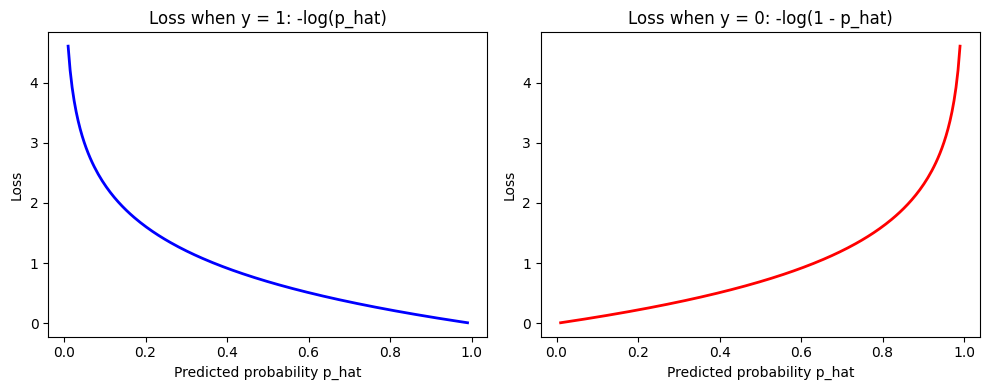

In [32]:
# Visualize cross-entropy loss
p_hat = np.linspace(0.01, 0.99, 200)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# When true label y=1
loss_y1 = -np.log(p_hat)
axes[0].plot(p_hat, loss_y1, 'b-', linewidth=2)
axes[0].set_xlabel("Predicted probability p_hat")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss when y = 1: -log(p_hat)")

# When true label y=0
loss_y0 = -np.log(1 - p_hat)
axes[1].plot(p_hat, loss_y0, 'r-', linewidth=2)
axes[1].set_xlabel("Predicted probability p_hat")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss when y = 0: -log(1 - p_hat)")

plt.tight_layout()
plt.savefig("figs/deep-learning-cross-entropy.png", dpi=150, bbox_inches="tight")

The key property: when the prediction is confident and wrong (e.g., $\hat{p} \approx 0$ when $y = 1$), the loss goes to infinity. This creates a strong gradient signal to correct the mistake.

### Question

Suppose we have a binary classification problem. Consider the following two predictions:

In [33]:
import numpy as np

# Prediction A: model is confident but wrong
p_hat_A, y_A = 0.9, 0
loss_A = -(y_A * np.log(p_hat_A) + (1 - y_A) * np.log(1 - p_hat_A))

# Prediction B: model is less confident but still wrong
p_hat_B, y_B = 0.6, 0
loss_B = -(y_B * np.log(p_hat_B) + (1 - y_B) * np.log(1 - p_hat_B))

What are `loss_A` and `loss_B`? How do they compare?

### Answer

For $\hat{p} = 0.9, y = 0$: $\mathcal{L} = -\log(1 - 0.9) = -\log(0.1) \approx 2.30$.
For $\hat{p} = 0.6, y = 0$: $\mathcal{L} = -\log(1 - 0.6) = -\log(0.4) \approx 0.92$.
The confident-but-wrong prediction ($\hat{p} = 0.9$) incurs about 2.5 times more loss. Cross-entropy heavily penalizes confident mistakes, which drives the network to become better calibrated.

## Backpropagation

Backpropagation is the algorithm that computes gradients of the loss with respect to all network parameters. It is simply the chain rule applied systematically through the computational graph.

### The chain rule on computational graphs

Consider computing $f(x) = (x + 2)^2$. We can break this into:

- $a = x + 2$ (addition node)
- $f = a^2$ (squaring node)

The derivative is: $\frac{df}{dx} = \frac{df}{da} \cdot \frac{da}{dx} = 2a \cdot 1 = 2(x + 2)$

Backpropagation traverses the graph in reverse, multiplying local derivatives along each edge.

### Backprop through a single neuron

For a single neuron: $z = wx + b$, $a = \sigma(z)$, $\mathcal{L} = (y - a)^2$

**Forward pass** (left to right):

1. $z = wx + b$
2. $a = \sigma(z)$
3. $\mathcal{L} = (y - a)^2$

**Backward pass** (right to left):

1. $\frac{\partial \mathcal{L}}{\partial a} = -2(y - a)$
2. $\frac{\partial \mathcal{L}}{\partial z} = \frac{\partial \mathcal{L}}{\partial a} \cdot \sigma'(z)$
3. $\frac{\partial \mathcal{L}}{\partial w} = \frac{\partial \mathcal{L}}{\partial z} \cdot x$, $\quad \frac{\partial \mathcal{L}}{\partial b} = \frac{\partial \mathcal{L}}{\partial z}$

In [34]:
# Numerical example of backpropagation through one neuron
x_val = 1.5
w_val = 0.8
b_val = 0.1
y_val = 1.0

# Forward pass
z_val = w_val * x_val + b_val
a_val = sigmoid(z_val)
loss_val = (y_val - a_val) ** 2

print("=== Forward Pass ===")
print(f"z = w*x + b = {w_val}*{x_val} + {b_val} = {z_val:.4f}")
print(f"a = sigmoid(z) = {a_val:.4f}")
print(f"L = (y - a)^2 = ({y_val} - {a_val:.4f})^2 = {loss_val:.4f}")

# Backward pass
dL_da = -2 * (y_val - a_val)
da_dz = a_val * (1 - a_val)  # sigmoid derivative
dL_dz = dL_da * da_dz
dL_dw = dL_dz * x_val
dL_db = dL_dz

print("\n=== Backward Pass ===")
print(f"dL/da = -2(y - a) = {dL_da:.4f}")
print(f"da/dz = sigmoid'(z) = {da_dz:.4f}")
print(f"dL/dz = dL/da * da/dz = {dL_dz:.4f}")
print(f"dL/dw = dL/dz * x = {dL_dw:.4f}")
print(f"dL/db = dL/dz = {dL_db:.4f}")

=== Forward Pass ===
z = w*x + b = 0.8*1.5 + 0.1 = 1.3000
a = sigmoid(z) = 0.7858
L = (y - a)^2 = (1.0 - 0.7858)^2 = 0.0459

=== Backward Pass ===
dL/da = -2(y - a) = -0.4283
da/dz = sigmoid'(z) = 0.1683
dL/dz = dL/da * da/dz = -0.0721
dL/dw = dL/dz * x = -0.1081
dL/db = dL/dz = -0.0721


### Backprop through a full network

For a multilayer network, backpropagation applies the chain rule layer by layer. Starting from the output:

1. Compute $\frac{\partial \mathcal{L}}{\partial z^{(L)}}$ at the output layer
2. For each layer $l$ from $L$ down to 1:
   - $\frac{\partial \mathcal{L}}{\partial W^{(l)}} = (h^{(l-1)})^T \frac{\partial \mathcal{L}}{\partial z^{(l)}}$
   - $\frac{\partial \mathcal{L}}{\partial b^{(l)}} = \sum_i \frac{\partial \mathcal{L}}{\partial z_i^{(l)}}$
   - $\frac{\partial \mathcal{L}}{\partial h^{(l-1)}} = \frac{\partial \mathcal{L}}{\partial z^{(l)}} (W^{(l)})^T$
   - $\frac{\partial \mathcal{L}}{\partial z^{(l-1)}} = \frac{\partial \mathcal{L}}{\partial h^{(l-1)}} \odot \sigma'(z^{(l-1)})$

where $\odot$ denotes elementwise multiplication.

The key insight: the forward pass saves intermediate values (the $h^{(l)}$ and $z^{(l)}$), and the backward pass uses them to compute gradients. This is why training neural networks requires more memory than inference.

Let's put this all together and train a 2-layer network from scratch using only numpy. We'll classify points as inside or outside a unit circle.

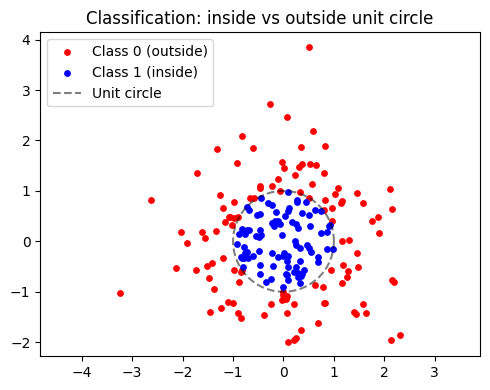

In [35]:
# Generate classification data: points inside vs outside a unit circle
np.random.seed(42)
n_samples = 200
X_train = np.random.randn(n_samples, 2)
y_train = (X_train[:, 0] ** 2 + X_train[:, 1] ** 2 < 1).astype(float).reshape(-1, 1)

plt.figure(figsize=(5, 4))
plt.scatter(X_train[y_train.ravel() == 0, 0], X_train[y_train.ravel() == 0, 1],
            s=15, c='red', label="Class 0 (outside)")
plt.scatter(X_train[y_train.ravel() == 1, 0], X_train[y_train.ravel() == 1, 1],
            s=15, c='blue', label="Class 1 (inside)")
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5, label="Unit circle")
plt.title("Classification: inside vs outside unit circle")
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.savefig("figs/deep-learning-circle-data.png", dpi=150, bbox_inches="tight")

A linear classifier cannot separate these two classes (the boundary is a circle, not a line). Let's train a 2-layer neural network with ReLU activations and binary cross-entropy loss, implementing every step of backpropagation by hand.

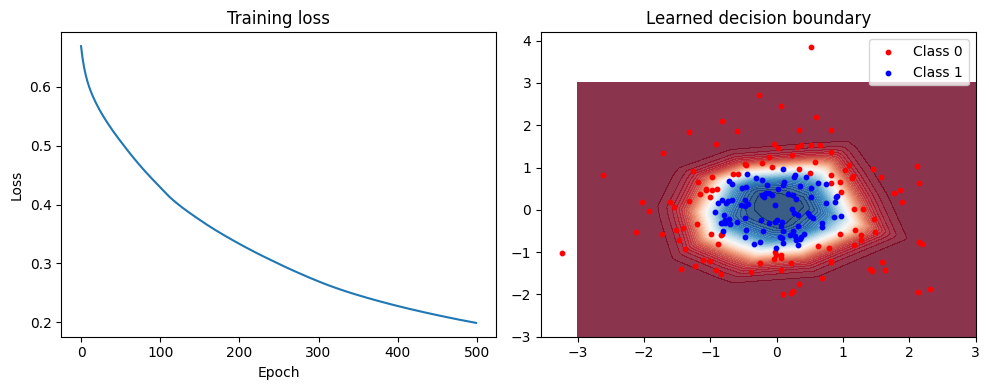

In [36]:
# Initialize weights
hidden_dim = 16
W1 = np.random.randn(2, hidden_dim) * 0.5
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, 1) * 0.5
b2 = np.zeros((1, 1))

lr = 0.1
losses = []

for epoch in range(500):
    # Forward pass
    z1 = X_train @ W1 + b1
    h1 = np.maximum(0, z1)  # ReLU
    z2 = h1 @ W2 + b2
    y_hat = sigmoid(z2)

    # Binary cross-entropy loss
    eps = 1e-8
    loss = -np.mean(y_train * np.log(y_hat + eps) + (1 - y_train) * np.log(1 - y_hat + eps))
    losses.append(loss)

    # Backward pass
    dz2 = (y_hat - y_train) / n_samples
    dW2 = h1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    dh1 = dz2 @ W2.T
    dz1 = dh1 * (z1 > 0)  # ReLU derivative
    dW1 = X_train.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Gradient descent update
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

# Plot training loss and decision boundary
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(losses, linewidth=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss")

xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
z1_grid = grid @ W1 + b1
h1_grid = np.maximum(0, z1_grid)
z2_grid = h1_grid @ W2 + b2
pred_grid = sigmoid(z2_grid).reshape(xx.shape)

axes[1].contourf(xx, yy, pred_grid, levels=50, cmap='RdBu', alpha=0.8)
axes[1].scatter(X_train[y_train.ravel() == 0, 0], X_train[y_train.ravel() == 0, 1], s=10, c='red', label="Class 0")
axes[1].scatter(X_train[y_train.ravel() == 1, 0], X_train[y_train.ravel() == 1, 1], s=10, c='blue', label="Class 1")
axes[1].set_title("Learned decision boundary")
axes[1].legend()

plt.tight_layout()
plt.savefig("figs/deep-learning-backprop-demo.png", dpi=150, bbox_inches="tight")

We trained a neural network from scratch using only numpy! The network learned a circular decision boundary to separate the two classes.

## Deep Learning with PyTorch

Writing backpropagation by hand is tedious and error-prone. PyTorch provides **automatic differentiation** (autograd) that computes gradients automatically. It also provides modules for defining layers, loss functions, and optimizers.

### Installing PyTorch

In [37]:
%pip install torch torchvision


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Tensors and autograd

PyTorch tensors are similar to numpy arrays but can track operations for automatic differentiation.

In [38]:
import torch

# Create tensors
x = torch.tensor([2.0, 3.0], requires_grad=True)
y = torch.tensor([4.0, 5.0], requires_grad=True)

# Computation
z = (x * y).sum()
print(f"z = sum(x * y) = {z.item()}")

# Automatic differentiation
z.backward()
print(f"dz/dx = y = {x.grad}")  # dz/dx = y
print(f"dz/dy = x = {y.grad}")  # dz/dy = x

z = sum(x * y) = 23.0
dz/dx = y = tensor([4., 5.])
dz/dy = x = tensor([2., 3.])


PyTorch builds a computational graph during the forward pass and uses it to compute gradients in the backward pass. This is the same backpropagation algorithm we implemented by hand, but automated.

### Defining a neural network

PyTorch's `nn.Module` provides a clean way to define networks:

In [39]:
import torch
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

model = SimpleNet(input_dim=2, hidden_dim=16, output_dim=1)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

SimpleNet(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=16, out_features=1, bias=True)
)
Total parameters: 65


Each `nn.Linear(in, out)` creates a layer with a weight matrix of shape `(out, in)` and a bias vector of shape `(out,)`.

### Training loop

The standard PyTorch training loop has four steps: forward pass, compute loss, backward pass, update parameters.

Epoch 100, Loss: 0.1088
Epoch 200, Loss: 0.0555
Epoch 300, Loss: 0.0369


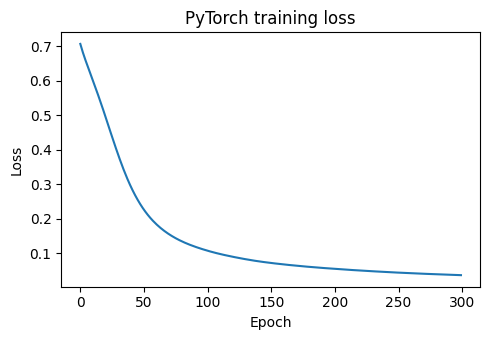

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim

# Prepare data
np.random.seed(42)
n_samples = 500
X_np = np.random.randn(n_samples, 2).astype(np.float32)
y_np = ((X_np[:, 0] ** 2 + X_np[:, 1] ** 2) < 1.5).astype(np.float32).reshape(-1, 1)

X_tensor = torch.from_numpy(X_np)
y_tensor = torch.from_numpy(y_np)

# Define model, loss, optimizer
model = SimpleNet(input_dim=2, hidden_dim=32, output_dim=1)
criterion = nn.BCEWithLogitsLoss()  # binary cross-entropy with sigmoid built in
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
train_losses = []
for epoch in range(300):
    # Forward pass
    logits = model(X_tensor)
    loss = criterion(logits, y_tensor)

    # Backward pass
    optimizer.zero_grad()   # clear previous gradients
    loss.backward()         # compute gradients

    # Update parameters
    optimizer.step()

    train_losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

plt.figure(figsize=(5, 3.5))
plt.plot(train_losses, linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch training loss")
plt.tight_layout()
plt.savefig("figs/deep-learning-pytorch-loss.png", dpi=150, bbox_inches="tight")

Let's break down the four key lines in the training loop:

1. **`logits = model(X_tensor)`** - Forward pass: computes predictions
2. **`loss = criterion(logits, y_tensor)`** - Computes the loss value
3. **`loss.backward()`** - Backward pass: computes all gradients via autograd
4. **`optimizer.step()`** - Updates all parameters using the computed gradients

The `optimizer.zero_grad()` call is necessary because PyTorch accumulates gradients by default. Without it, gradients from previous iterations would be added to current gradients.

### Question

Consider the following training loop. What would happen if we removed the `optimizer.zero_grad()` line? Would the model still train? Would it converge?

```python
for epoch in range(300):
    logits = model(X_tensor)
    loss = criterion(logits, y_tensor)

    optimizer.zero_grad()   # <-- what if we remove this?
    loss.backward()
    optimizer.step()
```

### Answer

The model would still update, but gradients would accumulate across iterations. In iteration $t$, the effective gradient would be the sum of gradients from iterations $1$ through $t$. This means the gradient magnitude grows over time, causing increasingly large parameter updates that can destabilize training. Whether it diverges depends on the learning rate and problem, but training will generally be unreliable. This is one of the most common PyTorch bugs. Interestingly, deliberate gradient accumulation (calling `backward()` multiple times before `step()`) is sometimes used to simulate larger batch sizes on limited GPU memory.

## Training on MNIST: A Complete Example

MNIST is a dataset of 70,000 handwritten digit images (28x28 pixels, grayscale). It is the classic "hello world" of deep learning.

![xkcd 2173: Trained a Neural Net](https://imgs.xkcd.com/comics/trained_a_neural_net.png)

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load MNIST data
transform = transforms.Compose([
    transforms.ToTensor(),           # convert image to tensor (scales to [0, 1])
    transforms.Normalize((0.1307,), (0.3081,))  # normalize with MNIST mean and std
])

# Note: the "HTTP Error 404" messages below are normal. The primary download server
# (yann.lecun.com) is no longer available, so torchvision automatically falls back
# to the S3 mirror. The data downloads successfully from the mirror.
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

### Visualizing the data

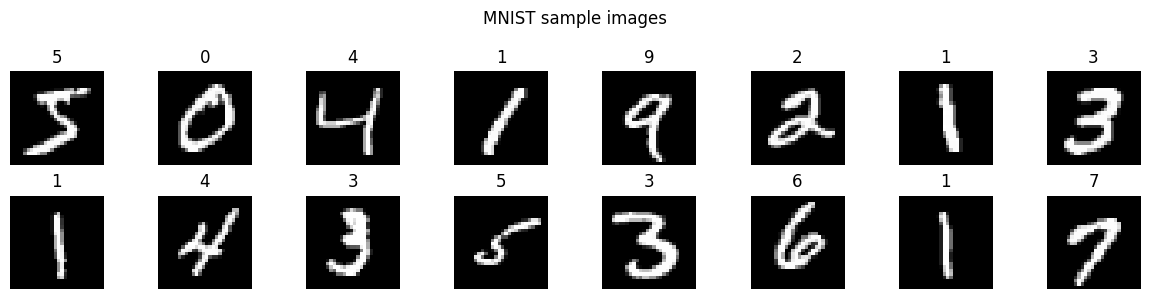

In [42]:
# Show some examples
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(str(label))
    ax.axis('off')
plt.suptitle("MNIST sample images")
plt.tight_layout()
plt.savefig("figs/deep-learning-mnist-samples.png", dpi=150, bbox_inches="tight")

### Defining the model

In [43]:
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()         # 28x28 -> 784
        self.layer1 = nn.Linear(784, 128)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(64, 10)     # 10 classes (digits 0-9)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.output(x)
        return x

model = MNISTNet()
criterion = nn.CrossEntropyLoss()           # includes softmax internally
optimizer = optim.Adam(model.parameters(), lr=0.001)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

Model parameters: 109,386


### Training

In [44]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for X_batch, y_batch in loader:
        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total += len(y_batch)
    return total_loss / total, correct / total

# Train for 5 epochs
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(5):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}: Train loss={train_loss:.4f}, acc={train_acc:.4f} | "
          f"Test loss={test_loss:.4f}, acc={test_acc:.4f}")

Epoch 1: Train loss=0.2774, acc=0.9174 | Test loss=0.1377, acc=0.9574
Epoch 2: Train loss=0.1140, acc=0.9653 | Test loss=0.1014, acc=0.9692
Epoch 3: Train loss=0.0836, acc=0.9739 | Test loss=0.0928, acc=0.9709
Epoch 4: Train loss=0.0621, acc=0.9804 | Test loss=0.0953, acc=0.9705
Epoch 5: Train loss=0.0507, acc=0.9838 | Test loss=0.0973, acc=0.9708


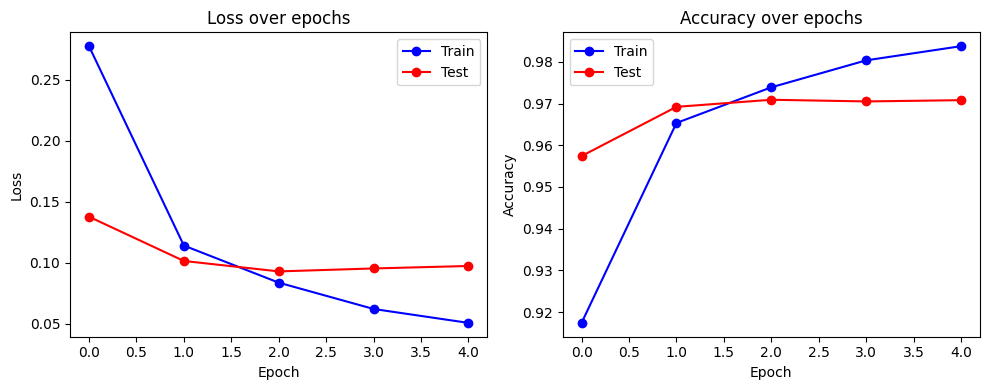

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(train_losses, 'b-o', label="Train")
axes[0].plot(test_losses, 'r-o', label="Test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over epochs")
axes[0].legend()

axes[1].plot(train_accs, 'b-o', label="Train")
axes[1].plot(test_accs, 'r-o', label="Test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over epochs")
axes[1].legend()

plt.tight_layout()
plt.savefig("figs/deep-learning-mnist-training.png", dpi=150, bbox_inches="tight")

With just a simple feedforward network, we can achieve ~97% accuracy on MNIST in a few epochs. More advanced architectures (convolutional neural networks) can reach >99%.

### Question

Our MNIST model architecture is: 784 -> 128 -> 64 -> 10. Consider a modified architecture: 784 -> 256 -> 128 -> 64 -> 10. How many total parameters does each model have?

In [46]:
# Original model
# layer1: Linear(784, 128), layer2: Linear(128, 64), output: Linear(64, 10)

# Modified model
# layer1: Linear(784, 256), layer2: Linear(256, 128),
# layer3: Linear(128, 64), output: Linear(64, 10)

### Answer

**Original**: $(784 \times 128 + 128) + (128 \times 64 + 64) + (64 \times 10 + 10) = 100{,}480 + 8{,}256 + 650 = 109{,}386$.
**Modified**: $(784 \times 256 + 256) + (256 \times 128 + 128) + (128 \times 64 + 64) + (64 \times 10 + 10) = 200{,}960 + 32{,}896 + 8{,}256 + 650 = 242{,}762$.
The modified model has more than twice as many parameters. More parameters give the model more capacity to fit complex patterns, but also increase computation and memory. For MNIST, the simple model already achieves high accuracy, so the additional capacity is unlikely to help much.

## Practical Training Tips

### Stochastic gradient descent and mini-batches

In Module 2, we learned full-batch gradient descent: compute the gradient using all $n$ data points, then update. For deep learning, this is impractical because:

1. Datasets are too large to fit in memory at once
2. Computing the full gradient is slow
3. Noisy gradients from small batches can actually help escape local minima

**Mini-batch gradient descent** computes the gradient on a random subset (batch) of the data:

$$\theta \leftarrow \theta - \eta \cdot \frac{1}{|B|}\sum_{i \in B} \nabla_\theta \mathcal{L}(x_i, y_i; \theta)$$

Common batch sizes are 32, 64, 128, or 256. Smaller batches introduce more noise (which can help generalization), while larger batches give more stable gradient estimates (which can help convergence speed).

### Learning rate

The learning rate $\eta$ is the most important hyperparameter. Too large and the optimization diverges. Too small and training is extremely slow.

Below we visualize gradient descent on the Rosenbrock function (a classic optimization test function with a narrow curved valley) using three different learning rates. The red path traces the optimizer's trajectory from the green starting point. When the learning rate is too small, the optimizer barely moves. A good learning rate makes steady progress toward the minimum. When it is too large, the optimizer overshoots and flies out of the valley.

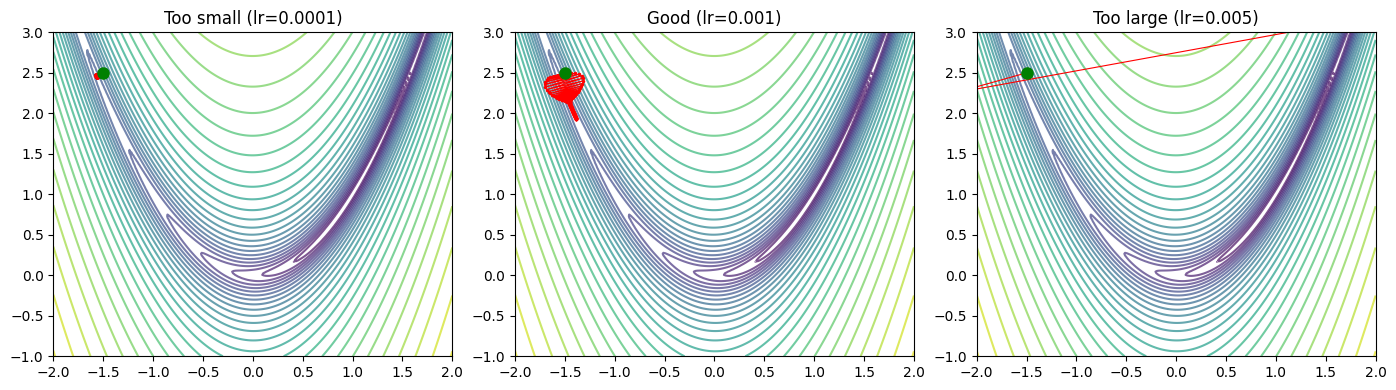

In [47]:
# Demonstrate learning rate effects
np.random.seed(42)

def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
lrs = [0.0001, 0.001, 0.005]
titles = ["Too small (lr=0.0001)", "Good (lr=0.001)", "Too large (lr=0.005)"]

for ax, lr_val, title in zip(axes, lrs, titles):
    # Contour plot
    xx = np.linspace(-2, 2, 200)
    yy = np.linspace(-1, 3, 200)
    XX, YY = np.meshgrid(xx, yy)
    ZZ = rosenbrock(XX, YY)
    ax.contour(XX, YY, np.log1p(ZZ), levels=30, cmap='viridis', alpha=0.7)

    # Run gradient descent
    point = np.array([-1.5, 2.5])
    path = [point.copy()]
    for _ in range(200):
        grad = rosenbrock_grad(point[0], point[1])
        point = point - lr_val * grad
        path.append(point.copy())
        if np.any(np.abs(point) > 10):
            break
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], 'r.-', markersize=3, linewidth=0.8)
    ax.plot(path[0, 0], path[0, 1], 'go', markersize=8)
    ax.set_title(title)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 3)

plt.tight_layout()
plt.savefig("figs/deep-learning-learning-rate.png", dpi=150, bbox_inches="tight")

**Learning rate schedules** reduce the learning rate over training. Common strategies:

- **Step decay**: multiply by 0.1 every $k$ epochs
- **Cosine annealing**: $\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})(1 + \cos(\frac{t}{T}\pi))$

### Optimizers

**SGD with momentum** uses an exponential moving average of past gradients:

$$v_t = \beta v_{t-1} + \nabla_\theta \mathcal{L}, \quad \theta \leftarrow \theta - \eta \cdot v_t$$

This helps accelerate training in directions with consistent gradient and dampens oscillation.

**Adam** (Adaptive Moment Estimation) adapts the learning rate for each parameter based on first and second moment estimates. It is the most commonly used optimizer in deep learning because it works well with default settings (`lr=0.001, betas=(0.9, 0.999)`).

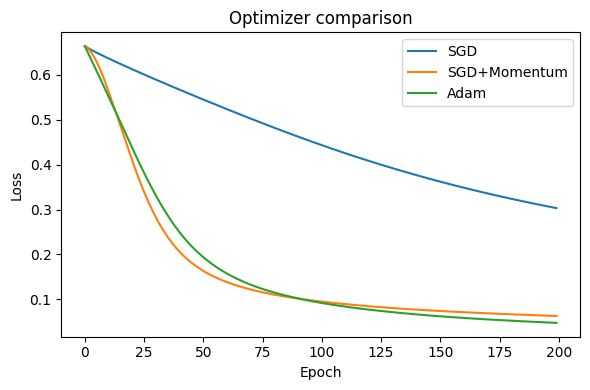

In [48]:
# Compare optimizers on the same problem
import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
X_np = np.random.randn(500, 2).astype(np.float32)
y_np = ((X_np[:, 0] ** 2 + X_np[:, 1] ** 2) < 1.5).astype(np.float32).reshape(-1, 1)
X_t = torch.from_numpy(X_np)
y_t = torch.from_numpy(y_np)

fig, ax = plt.subplots(figsize=(6, 4))

for opt_name, opt_class, kwargs in [
    ("SGD", optim.SGD, {"lr": 0.1}),
    ("SGD+Momentum", optim.SGD, {"lr": 0.1, "momentum": 0.9}),
    ("Adam", optim.Adam, {"lr": 0.01}),
]:
    torch.manual_seed(42)
    net = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 1))
    criterion = nn.BCEWithLogitsLoss()
    opt = opt_class(net.parameters(), **kwargs)

    losses = []
    for epoch in range(200):
        logits = net(X_t)
        loss = criterion(logits, y_t)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

    ax.plot(losses, label=opt_name, linewidth=1.5)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Optimizer comparison")
ax.legend()
plt.tight_layout()
plt.savefig("figs/deep-learning-optimizers.png", dpi=150, bbox_inches="tight")

### Question

SGD with momentum updates the velocity and parameters as follows:

```python
# Momentum update (simplified pseudocode)
beta = 0.9
v = beta * v + gradient       # velocity update
theta = theta - lr * v        # parameter update
```

If the gradient is constant (same value $g$ at every step), what does the velocity $v_t$ converge to?

### Answer

If the gradient is always $g$, the velocity follows the geometric series: $v_t = g + \beta g + \beta^2 g + \cdots = \frac{g}{1-\beta}$. With $\beta = 0.9$, this converges to $\frac{g}{0.1} = 10g$. So momentum effectively amplifies the effective learning rate by $\frac{1}{1-\beta} = 10\times$ in directions where the gradient is consistent. This is why momentum accelerates convergence along consistent gradient directions.

## Overfitting and Regularization

Deep neural networks have many parameters and can easily memorize training data. Overfitting occurs when the model performs well on training data but poorly on unseen test data.

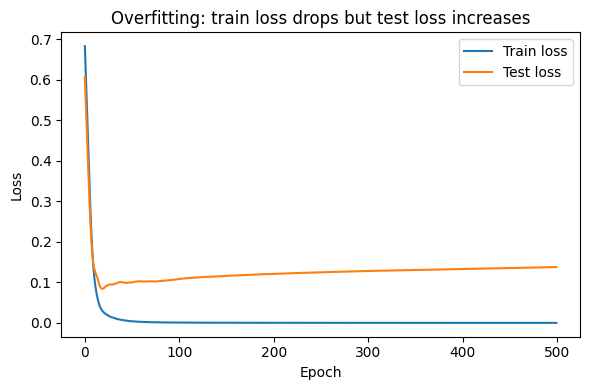

In [49]:
# Demonstrate overfitting
import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
# Small dataset, easy to overfit
n_small = 50
X_small = np.random.randn(n_small, 2).astype(np.float32)
y_small = ((X_small[:, 0] ** 2 + X_small[:, 1] ** 2) < 1).astype(np.float32).reshape(-1, 1)

# Large test set
n_test = 500
X_test = np.random.randn(n_test, 2).astype(np.float32)
y_test = ((X_test[:, 0] ** 2 + X_test[:, 1] ** 2) < 1).astype(np.float32).reshape(-1, 1)

X_sm_t = torch.from_numpy(X_small)
y_sm_t = torch.from_numpy(y_small)
X_te_t = torch.from_numpy(X_test)
y_te_t = torch.from_numpy(y_test)

# Overly large network for the small dataset
torch.manual_seed(42)
big_net = nn.Sequential(
    nn.Linear(2, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 1)
)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(big_net.parameters(), lr=0.01)

train_l, test_l = [], []
for epoch in range(500):
    # Train
    big_net.train()
    logits = big_net(X_sm_t)
    loss = criterion(logits, y_sm_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_l.append(loss.item())

    # Evaluate
    big_net.eval()
    with torch.no_grad():
        test_loss = criterion(big_net(X_te_t), y_te_t).item()
    test_l.append(test_loss)

plt.figure(figsize=(6, 4))
plt.plot(train_l, label="Train loss", linewidth=1.5)
plt.plot(test_l, label="Test loss", linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overfitting: train loss drops but test loss increases")
plt.legend()
plt.tight_layout()
plt.savefig("figs/deep-learning-overfitting.png", dpi=150, bbox_inches="tight")

The classic sign of overfitting: training loss keeps decreasing while test loss starts increasing after some point.

### Regularization techniques

**Weight decay (L2 regularization)** adds a penalty on the magnitude of the weights: $\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{data}} + \lambda \sum_l \|W^{(l)}\|_F^2$

This is the same ridge penalty from linear regression. In PyTorch, set the `weight_decay` parameter in the optimizer:

In [50]:
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

**Dropout** randomly sets a fraction of hidden units to zero during training. This prevents neurons from co-adapting and forces the network to learn more robust features. At test time, all neurons are active but scaled accordingly.

![Dropout illustration (d2l.ai)](https://d2l.ai/_images/dropout2.svg)

In [51]:
class RegularizedNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.5):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)
        self.output = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.layer1(x)))
        x = self.dropout2(self.relu2(self.layer2(x)))
        x = self.output(x)
        return x

**Early stopping** monitors validation loss and stops training when it starts increasing. This is simple and effective.

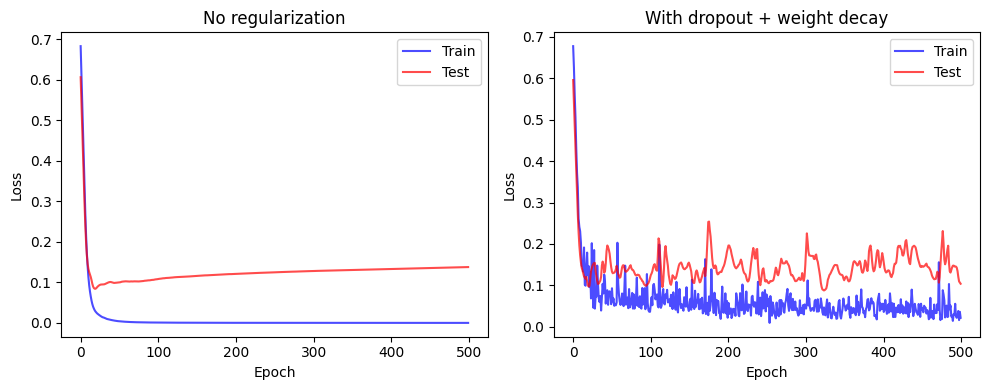

In [52]:
# Compare with and without regularization
torch.manual_seed(42)
reg_net = nn.Sequential(
    nn.Linear(2, 128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 1)
)
optimizer_reg = optim.Adam(reg_net.parameters(), lr=0.01, weight_decay=1e-3)

train_l_reg, test_l_reg = [], []
for epoch in range(500):
    reg_net.train()
    logits = reg_net(X_sm_t)
    loss = criterion(logits, y_sm_t)
    optimizer_reg.zero_grad()
    loss.backward()
    optimizer_reg.step()
    train_l_reg.append(loss.item())

    reg_net.eval()
    with torch.no_grad():
        test_loss = criterion(reg_net(X_te_t), y_te_t).item()
    test_l_reg.append(test_loss)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(train_l, 'b-', alpha=0.7, label="Train", linewidth=1.5)
axes[0].plot(test_l, 'r-', alpha=0.7, label="Test", linewidth=1.5)
axes[0].set_title("No regularization")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(train_l_reg, 'b-', alpha=0.7, label="Train", linewidth=1.5)
axes[1].plot(test_l_reg, 'r-', alpha=0.7, label="Test", linewidth=1.5)
axes[1].set_title("With dropout + weight decay")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("figs/deep-learning-regularization.png", dpi=150, bbox_inches="tight")

### Question

Consider a layer with dropout during training and inference:

```python
# During training (dropout rate p=0.5)
mask = np.random.binomial(1, 1 - p, size=h.shape)  # random 0/1 mask
h_train = h * mask                                   # zero out ~50% of neurons

# During inference (no dropout, but scale)
h_test = h * (1 - p)                                 # scale by (1 - p)
```

Why is the `(1 - p)` scaling necessary at test time?

### Answer

During training with dropout rate $p$, each neuron's output is zero with probability $p$ and its actual value with probability $1-p$. So the expected output of a neuron during training is $(1-p) \cdot a$. At test time, when all neurons are active, the output is $a$. To keep the expected output consistent between training and test, we scale by $(1-p)$ at test time (or equivalently, PyTorch scales by $\frac{1}{1-p}$ during training so no scaling is needed at test). Without this, test-time activations would be systematically larger than during training, degrading performance.

## PyTorch Lightning

As models and training pipelines grow more complex, the standard PyTorch training loop becomes repetitive. PyTorch Lightning is a lightweight wrapper around PyTorch that separates the research code (model, loss, optimizer) from the engineering code (training loop, logging, checkpointing, distributed training).

### Installing PyTorch Lightning

In [ ]:
%pip install lightning

### From PyTorch to Lightning

A `LightningModule` organizes your code into a standard structure:

In [ ]:
import lightning as L
import torch
import torch.nn as nn
import torch.optim as optim

class MNISTLightning(L.LightningModule):
    def __init__(self, lr=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(784, 128)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(64, 10)
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        return self.output(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.hparams.lr)

Compare this with the raw PyTorch training loop we wrote earlier. The `LightningModule` encapsulates three things:

1. **Model architecture** (`__init__` and `forward`)
2. **Training logic** (`training_step` and `validation_step`)
3. **Optimizer configuration** (`configure_optimizers`)

The training loop, gradient zeroing, `loss.backward()`, `optimizer.step()`, `model.train()`/`model.eval()`, and `torch.no_grad()` are all handled by the `Trainer`:

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1000, shuffle=False)

model = MNISTLightning(lr=0.001)
trainer = L.Trainer(max_epochs=5)
trainer.fit(model, train_loader, val_loader)

The `Trainer` handles the entire training loop. Beyond eliminating boilerplate, Lightning provides built-in support for logging, checkpointing, early stopping, learning rate scheduling, and multi-GPU training, all without changing your model code.

## A Taste of Architectures

While feedforward networks are the foundation, several specialized architectures have been developed for different data types.

### Convolutional neural networks (CNNs)

CNNs exploit spatial structure in images using local filters that slide across the input. Instead of connecting every input pixel to every hidden neuron, a convolutional layer applies small learned filters (e.g., 3x3) that detect local patterns like edges, textures, and shapes.

In [ ]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(14, 4))

# Layer specifications: (label, width, height, color)
layers = [
    ("Input\n28×28×1", 0.8, 2.8, "#B3E5FC"),
    ("Conv1+ReLU\n28×28×16", 1.0, 2.8, "#FFCC80"),
    ("MaxPool\n14×14×16", 0.7, 2.0, "#A5D6A7"),
    ("Conv2+ReLU\n14×14×32", 1.0, 2.0, "#FFCC80"),
    ("MaxPool\n7×7×32", 0.7, 1.4, "#A5D6A7"),
    ("Flatten\n1568", 0.4, 3.0, "#CE93D8"),
    ("FC\n10", 0.4, 0.8, "#EF9A9A"),
]

center_y = 2.0
x_pos = 0.5
gap = 0.4

for i, (name, w, h, color) in enumerate(layers):
    y = center_y - h / 2
    rect = patches.FancyBboxPatch(
        (x_pos, y), w, h,
        boxstyle="round,pad=0.05",
        facecolor=color, edgecolor="black", linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(x_pos + w / 2, y - 0.15, name,
            ha="center", va="top", fontsize=7.5, fontweight="bold")
    if i < len(layers) - 1:
        ax.annotate("", xy=(x_pos + w + gap - 0.05, center_y),
                     xytext=(x_pos + w + 0.05, center_y),
                     arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
    x_pos += w + gap

ax.set_xlim(0, x_pos)
ax.set_ylim(-0.5, 4.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("CNN Architecture for MNIST Classification", fontsize=11, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("figs/deep-learning-cnn-architecture.png", dpi=150, bbox_inches="tight")

In [53]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # 1 channel -> 16 filters
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)         # 28x28 -> 14x14
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)         # 14x14 -> 7x7
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc(x)
        return x

cnn = SimpleCNN()
total_params = sum(p.numel() for p in cnn.parameters())
print(f"CNN parameters: {total_params:,}")

CNN parameters: 20,490


The CNN has far fewer parameters than a fully connected network because filters are shared across spatial locations (translation equivariance).

### Recurrent neural networks (RNNs)

RNNs process sequential data by maintaining a hidden state that is updated at each time step. At time step $t$:

$$h_t = \sigma(W_h h_{t-1} + W_x x_t + b)$$

This allows the network to model dependencies across time steps. Variants like LSTM and GRU address the vanishing gradient problem in long sequences.

![Unrolled RNN (colah.github.io)](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/RNN-unrolled.png)

### Transformers

Transformers use self-attention to process sequences in parallel rather than sequentially. They are the foundation of modern large language models (GPT, BERT, etc.). We will cover transformers in detail in later lectures.

![Transformer encoder-decoder (jalammar.github.io)](https://jalammar.github.io/images/t/The_transformer_encoder_decoder_stack.png)

## Summary

| Concept | Key Idea |
|---------|----------|
| Neural networks | Compositions of linear transformations + nonlinear activations |
| Activation functions | ReLU for hidden layers, sigmoid/softmax for outputs |
| Loss functions | Cross-entropy = negative log-likelihood (connects to MLE) |
| Backpropagation | Chain rule applied to the computational graph |
| PyTorch | Autograd computes gradients automatically |
| Overfitting | Monitor train vs test loss; use dropout, weight decay, early stopping |
| Optimizers | Adam is a good default; SGD+momentum for fine-tuning |

The deep learning ecosystem is vast, but the core ideas are simple: define a differentiable model, choose a loss function, and optimize with gradient descent. Everything else is engineering and architecture design.

## Recommended Resources

* [3Blue1Brown: Neural Networks](https://www.3blue1brown.com/topics/neural-networks) - Excellent visual explanations
* [Dive into Deep Learning (d2l.ai)](http://d2l.ai/) - Interactive textbook with code
* [PyTorch Tutorials](https://pytorch.org/tutorials/) - Official PyTorch tutorials
* [Christopher Olah: Backpropagation](https://colah.github.io/posts/2015-08-Backprop/) - Clear explanation of computational graphs
* [Stanford CS231n](https://cs231n.github.io/) - Comprehensive lecture notes on deep learning for vision